# Downloading the data and computing log-returns


In [1]:
# Requirements:
#   pip install yfinance pandas numpy matplotlib statsmodels scipy
#

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm, probplot

# ----------------------------
# 1) Download S&P 500 data
# ----------------------------
ticker = "^GSPC"
start_date = "2003-01-01"
end_date = "2007-12-31"

df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust= False,
)

# ---- FIX: flatten columns if MultiIndex ----
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep Close prices
df = df.dropna(subset=["Close"])
price = df["Close"].astype(float)

#  Log-returns

log_ret = np.log(price).diff().dropna()


# Plotting Prices and Log-Returns

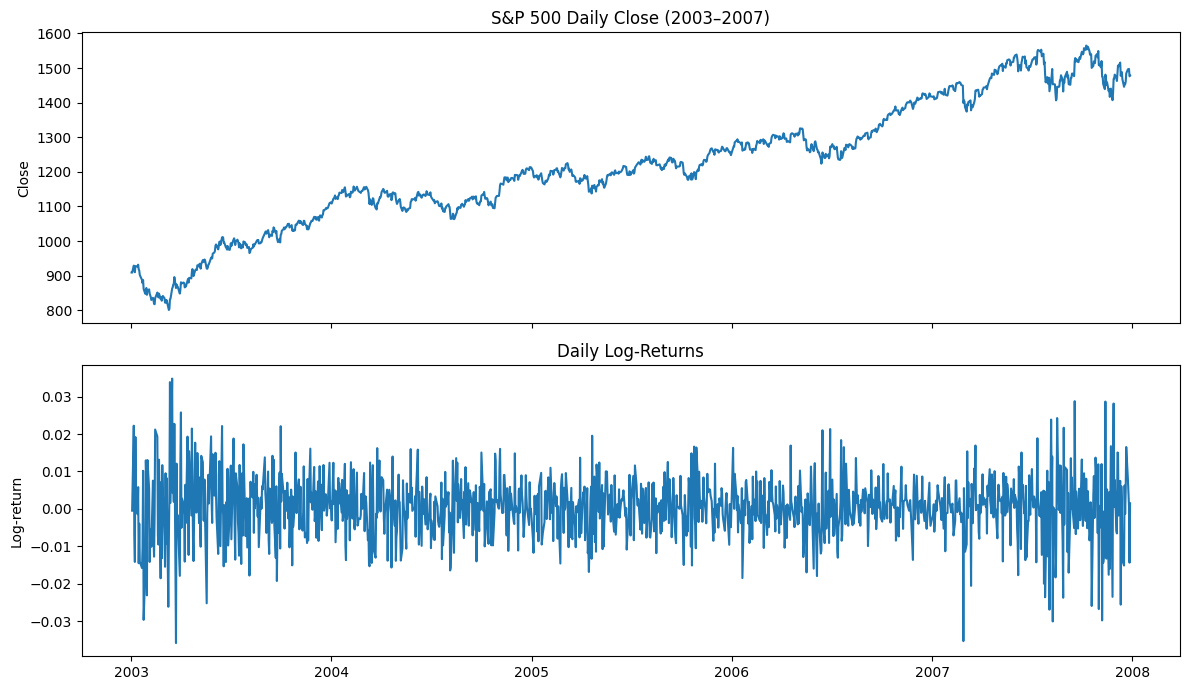

In [2]:

# ----------------------------
# 2x1 plot: prices and log-returns
# ----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(price.index, price)
axes[0].set_title("S&P 500 Daily Close (2003–2007)")
axes[0].set_ylabel("Close")

axes[1].plot(log_ret.index, log_ret)
axes[1].set_title("Daily Log-Returns")
axes[1].set_ylabel("Log-return")

plt.tight_layout()
plt.show()


# Fitting a Normal Distribution

In [3]:

# ----------------------------
#  Normal fit
# ----------------------------
mu_hat, sigma_hat = norm.fit(log_ret.values)
print(f"Normal fit: mu = {mu_hat:.6f}, sigma = {sigma_hat:.6f}")


Normal fit: mu = 0.000387, sigma = 0.008283


# Diagnostics Normal Distribution

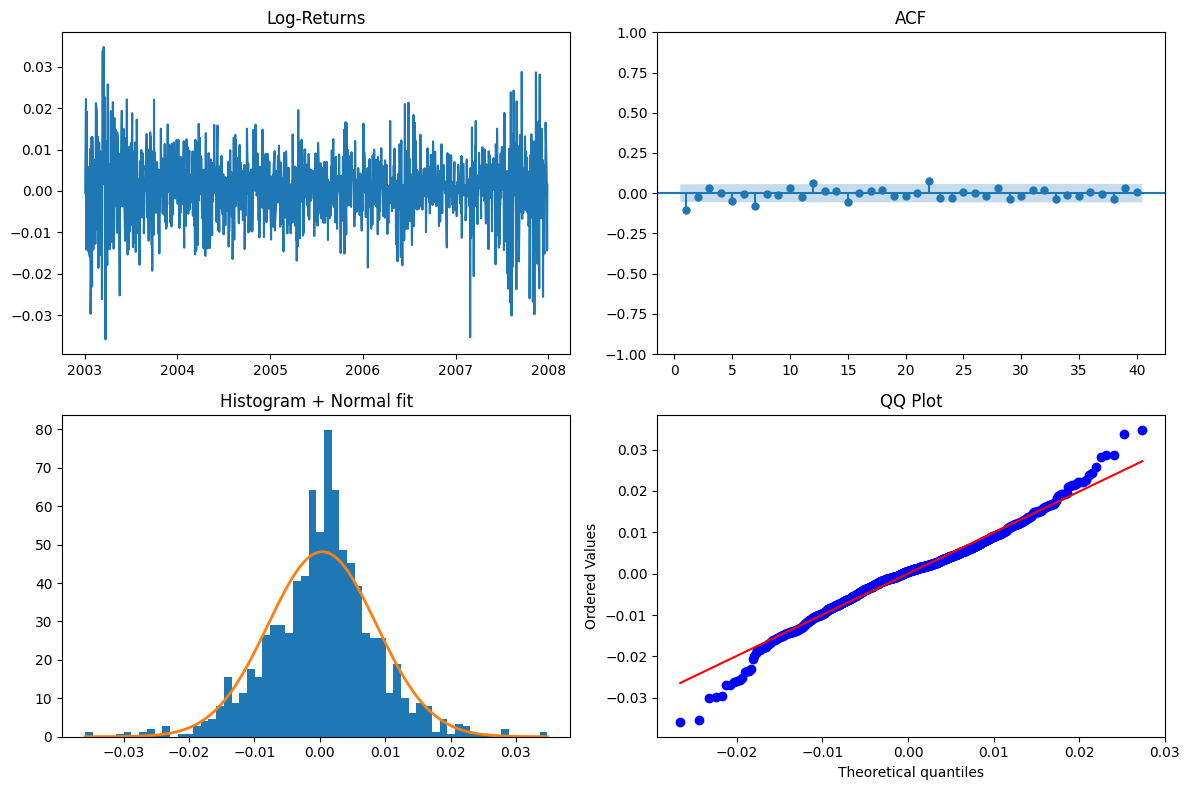

In [4]:

# ----------------------------
# 2x2 diagnostics plots
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Time series
axes[0, 0].plot(log_ret.index, log_ret)
axes[0, 0].set_title("Log-Returns")

# ACF
plot_acf(log_ret.values, lags=40, zero=False, ax=axes[0, 1])
axes[0, 1].set_title("ACF")

# Histogram + Normal
x = log_ret.values
axes[1, 0].hist(x, bins=60, density=True)
x_grid = np.linspace(x.min(), x.max(), 400)
axes[1, 0].plot(x_grid, norm.pdf(x_grid, mu_hat, sigma_hat), linewidth=2)
axes[1, 0].set_title("Histogram + Normal fit")

# QQ plot
probplot(x, dist="norm", sparams=(mu_hat, sigma_hat), plot=axes[1, 1])
axes[1, 1].set_title("QQ Plot")

plt.tight_layout()
plt.show()


# Absolute Log-Returns and Rolling SD
The following plot is a bit different than the one in the slides, since it does not include the year 2008.

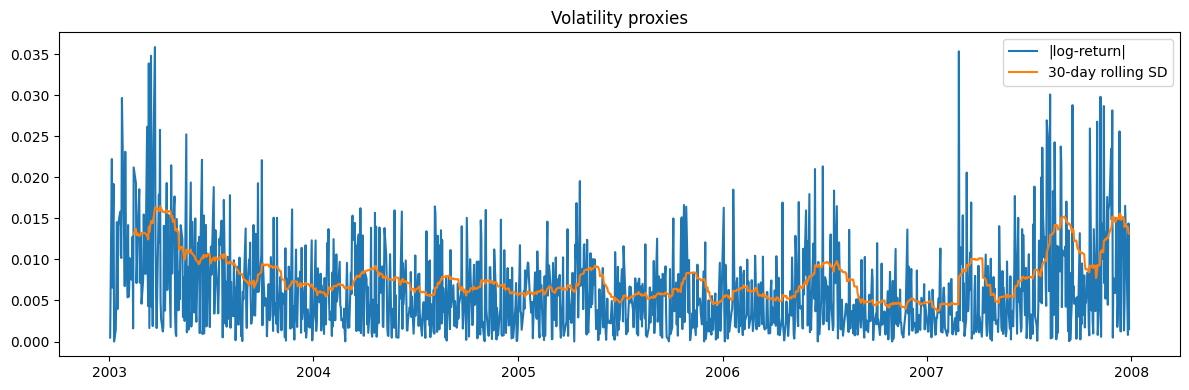

In [5]:
# ----------------------------
# |log-returns| and rolling SD
# ----------------------------
abs_log_ret = log_ret.abs()
roll_sd_30 = log_ret.rolling(30).std()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(abs_log_ret.index, abs_log_ret, label="|log-return|")
ax.plot(roll_sd_30.index, roll_sd_30, label="30-day rolling SD")
ax.set_title("Volatility proxies")
ax.legend()

plt.tight_layout()
plt.show()
